## 25-03-2026

## Week 5 Assignment Ridge and Lasso Regression

## Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.preprocessing import StandardScaler

## Loading Salary Dataset

In [4]:
import pandas as pd

df = pd.read_csv(r'C:\Users\saba\Downloads\Salary Data.csv')
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


## Section 1: Data Understanding
Question 1:  How many rows and columns are present in the dataset?


In [6]:
df.shape

(375, 6)

Question 2: Which columns have missing values, and how many missing values are there in each?

In [7]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Question 3: Identify the categorical and numerical columns in the dataset.

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Gender', 'Education Level', 'Job Title'], dtype='str')
Numerical Columns: Index(['Age', 'Years of Experience', 'Salary'], dtype='str')


C:\Users\saba\AppData\Local\Temp\ipykernel_14356\901792811.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Question 4:  Calculate the mean, median, and standard deviation of the Age column.

In [9]:
print("Mean:", df['Age'].mean())
print("Median:", df['Age'].median())
print("Standard Deviation:", df['Age'].std())

Mean: 37.43163538873995
Median: 36.0
Standard Deviation: 7.069072938567494


Question 5: Which gender has a higher proportion in the dataset? Provide percentages.

In [10]:
gender_Per = df['Gender'].value_counts(normalize=True) * 100
print(gender_Per)

Gender
Male      52.010724
Female    47.989276
Name: proportion, dtype: float64


Question 6: List the unique education levels and their proportion in the dataset.

In [15]:
# Solving using value_count
edu_counts = df['Education Level'].value_counts(normalize=True) * 100
print(edu_counts)

Education Level
Bachelor's    60.053619
Master's      26.273458
PhD           13.672922
Name: proportion, dtype: float64


In [14]:
# solving suing unique function
unique_levels = df['Education Level'].unique()
print(unique_levels)

<StringArray>
['Bachelor's', 'Master's', 'PhD', nan]
Length: 4, dtype: str


## Section 2: Data Cleaning & Preprocessing
Question 7: How many rows contain all NaN values? How would you handle these rows?

In [16]:
# Finding rows with NaN
NaN_rows = df.isnull().all(axis=1).sum()
print(NaN_rows)

2


In [19]:
# Handling NaN 
df = df.dropna(how='all')

Question 8: How many duplicate rows are present in the dataset? What effect might keeping
duplicates have on model performance?

In [20]:
duplicate_rows = df.duplicated().sum()
print(duplicate_rows)

49


Question 9: Why is it important to reset the index after removing duplicates and NaN rows?

In [22]:
# Reseting index is important to maintain continuous index
# Fixing index also prevent index mismatch issues during analysis

In [ ]:
# Fixing index
df = df.reset_index(drop=True)
df.head(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0


Question 10: Explain why we need to encode categorical variables before building a predictive model.

In [23]:
# Machine learning models work with numerical data only
# Categorical data (text) must be converted to numbers 
# Encoding helps model to understand and process features only

## Section 3: Exploratory Data Analysis (EDA)
Question 11: . Plot the distribution of Age. Comment on its skewness.

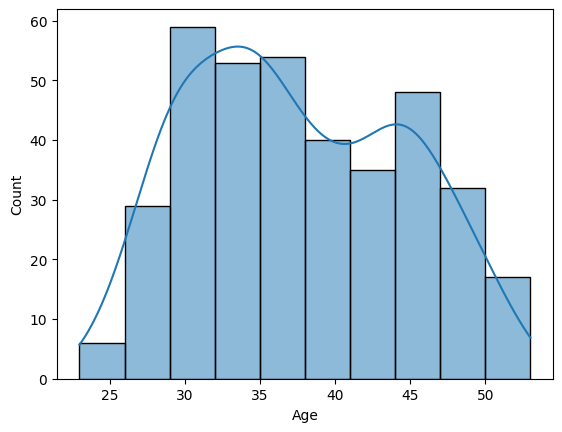

In [24]:
sns.histplot(df['Age'], kde=True)
plt.show()

In [ ]:
# Comment on shape:
# The Age distribution is slightly positively skewed (right-skewed)
# Most employees are younger (30–35), with fewer older employees

Question 12: Plot the distribution of Years of Experience. What can you infer about the
experience levels of employees?

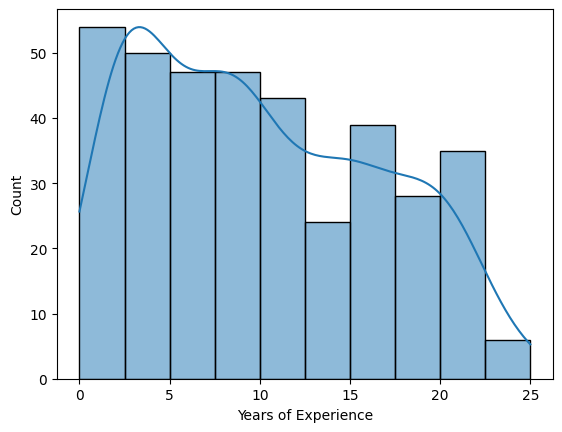

In [25]:
sns.histplot(df['Years of Experience'], kde=True)
plt.show()

In [ ]:
# Inference:
# Most employees are junior or early-career (0–10 years experience)
# The dataset contains fewer senior-level employees (15+ years)
# Overall distribution is right-skewed (positively skewed)
# This suggests the company/workforce is dominated by less experienced staff

Question 13: Plot a boxplot of Salary vs Education Level. What insights can you derive from this
visualization?

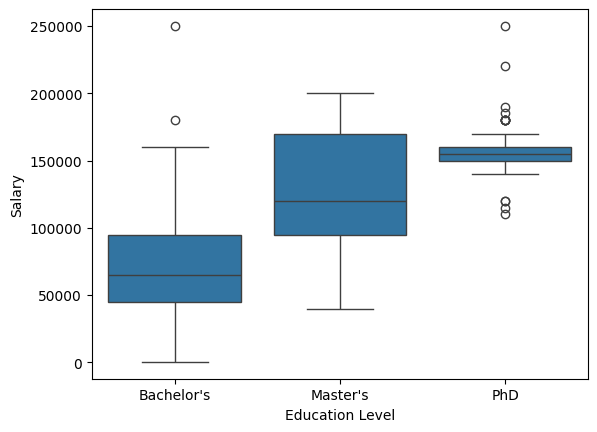

In [27]:
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.show()

In [ ]:
# Insights:
# Median salary increases significantly with each higher level of education (PhD > Master's > Bachelor's).
# PhD salaries are the most consistent (tightest distribution), while Master's salaries show the highest variability (widest range)
# Higher education levels significantly raise the minimum "typical" salary, with PhD holders having the highest entry-level floor.
# Exceptional outliers earning ~$250,000 exist across all three education levels, regardless of the group's average.

Question 14: Calculate the average salary by gender. Which gender earns more on average?


In [ ]:
avg_salary_gender = df.groupby('Gender')['Salary'].mean()
print(avg_salary_gender)
# higer the value means higher earning (Male have high earning value)

Gender
Female     97011.173184
Male      103867.783505
Name: Salary, dtype: float64


Question 15:  How does education level influence the average salary?

In [30]:
avg_salary_edu = df.groupby('Education Level')['Salary'].mean()
print(avg_salary_edu)
# Higher education have high average salary

Education Level
Bachelor's     74756.026786
Master's      129795.918367
PhD           157843.137255
Name: Salary, dtype: float64


Question 16:  How do years of experience influence salary? Divide experience into 5 categories:
○ 0–5 years
○ 6–10 years
○ 11–15 years
○ 16–20 years
○ 20+ years

In [31]:
bins = [0, 5, 10, 15, 20, 100]
labels = ['0-5', '6-10', '11-15', '16-20', '20+']

df['Experience Group'] = pd.cut(df['Years of Experience'], bins=bins, labels=labels)

avg_salary_exp = df.groupby('Experience Group')['Salary'].mean()
print(avg_salary_exp)

Experience Group
0-5       49367.372881
6-10      92578.947368
11-15    118230.769231
16-20    159140.625000
20+      175892.857143
Name: Salary, dtype: float64


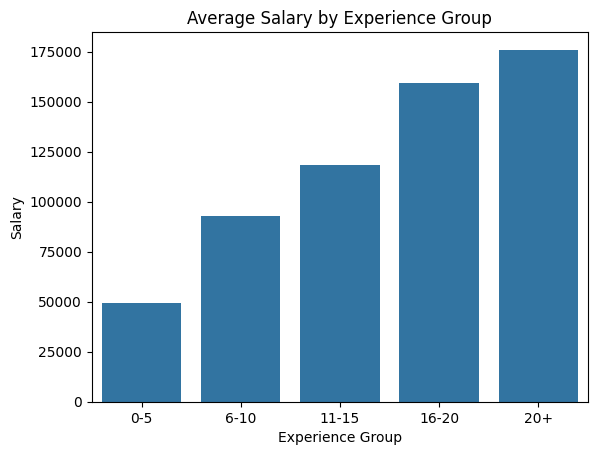

In [34]:
bins = [0, 5, 10, 15, 20, 100]
labels = ['0-5', '6-10', '11-15', '16-20', '20+']

df['Experience Group'] = pd.cut(df['Years of Experience'], bins=bins, labels=labels)

avg_salary_exp = df.groupby('Experience Group')['Salary'].mean().reset_index()

sns.barplot(x='Experience Group', y='Salary', data=avg_salary_exp)
plt.title("Average Salary by Experience Group")
plt.show()

## Section 4: Correlation & Relationships
Question 17: Create a correlation heatmap of numerical columns. Which features are strongly
correlated with Salary?

In [35]:
# Select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])
num_df

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0
...,...,...,...
368,35.0,8.0,85000.0
369,43.0,19.0,170000.0
370,29.0,2.0,40000.0
371,34.0,7.0,90000.0


In [37]:
# Correlation matrix
corr = num_df.corr()
corr

,Age,Years of Experience,Salary
Age,1.000000,0.979128,0.922335
Years of Experience,0.979128,1.000000,0.930338
Salary,0.922335,0.930338,1.000000


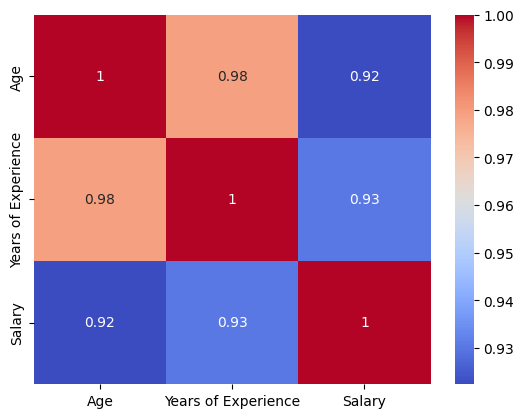

In [38]:
# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [39]:
# Correlation with Salary
print(corr['Salary'].sort_values(ascending=False))

Salary                 1.000000
Years of Experience    0.930338
Age                    0.922335
Name: Salary, dtype: float64


In [42]:
# Features strongly related with salary:
# Year of experience: Extremely strong positive correation(0.93) with salary
# Age: Very strong positive correlation (0.92) with Salary.
# Both features are nearly perfect predictors of Salary, with Years of Experience being slightly more influential.

Question 18: Create a scatter matrix for numerical variables. Which relationships appear linear?

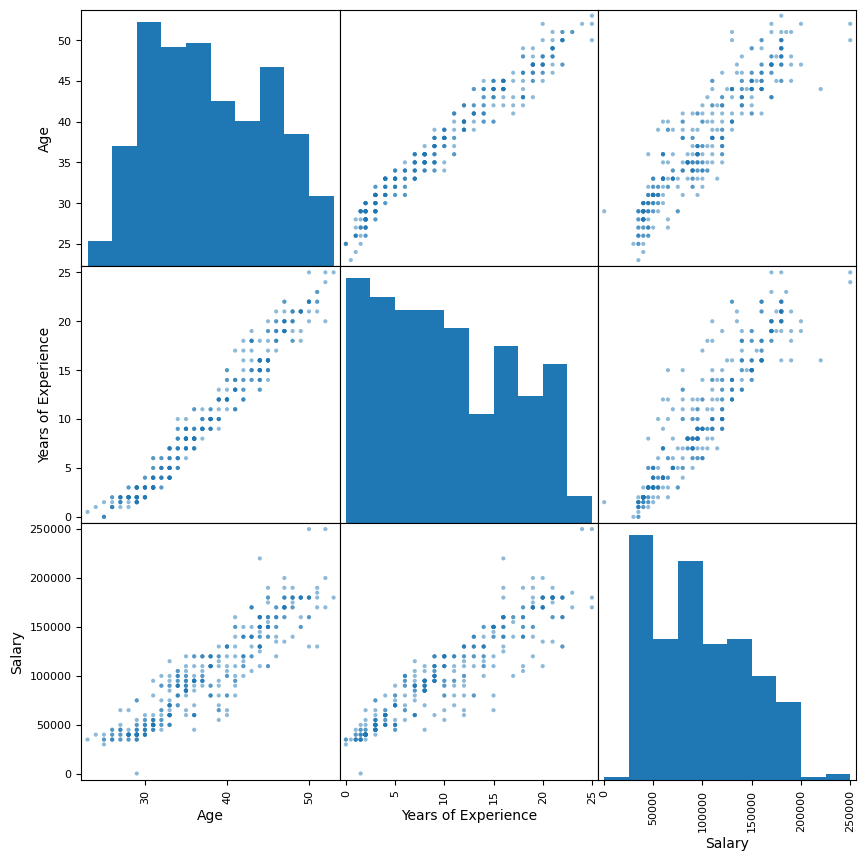

In [40]:
from pandas.plotting import scatter_matrix
scatter_matrix(num_df, figsize=(10, 10))
plt.show()

In [ ]:
# Age vs. Years of Experience: Shows the strongest, most direct linear relationship (points follow a very tight straight line).
# Years of Experience vs. Salary: Shows a clear positive linear trend; as experience increases, salary increases consistently.
# Age vs. Salary: Also shows a strong positive linear relationship, with salary increasing steadily as age increases.

## Section 5: Model Building

Drop rows with any NaN values (linear regression can't handle NaN values)

In [47]:
df_clean = df.dropna()  # removes rows with any NaN values
df_clean = df_clean.reset_index(drop=True)  # reset index

Encode categorical variables

In [49]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)
df_encoded

,Age,Years of Experience,Salary,Gender_Male,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,...,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer,Experience Group_6-10,Experience Group_11-15,Experience Group_16-20,Experience Group_20+
0,32.0,5.0,90000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,3.0,65000.0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,15.0,150000.0,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,36.0,7.0,60000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,52.0,20.0,200000.0,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,35.0,8.0,85000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
366,43.0,19.0,170000.0,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
367,29.0,2.0,40000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
368,34.0,7.0,90000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


Question 19: Which columns are selected as features (X) and which as the target (y) for prediction?

In [50]:
X = df_encoded.drop("Salary", axis=1)
y = df_encoded["Salary"]

print(X.columns)
print(y.name)

Index(['Age', 'Years of Experience', 'Gender_Male', 'Education Level_Master's',
       'Education Level_PhD', 'Job Title_Accountant',
       'Job Title_Administrative Assistant', 'Job Title_Business Analyst',
       'Job Title_Business Development Manager',
       'Job Title_Business Intelligence Analyst',
       ...
       'Job Title_Training Specialist', 'Job Title_UX Designer',
       'Job Title_UX Researcher', 'Job Title_VP of Finance',
       'Job Title_VP of Operations', 'Job Title_Web Developer',
       'Experience Group_6-10', 'Experience Group_11-15',
       'Experience Group_16-20', 'Experience Group_20+'],
      dtype='str', length=179)
Salary


Question 20: What is the purpose of splitting the dataset into training and testing sets?

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Purpose of data splitting:
# Training set because model learns patterns
# Testing set so that model is evaluated on unseen data
# Prevents overfitting

Question 21: What algorithm is used for prediction? Why is it suitable for this problem?

In [52]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Question 22:  After fitting the model, what is the training score?

In [53]:
train_score = model.score(X_train, y_train)
print("Training Score:", train_score)

Training Score: 0.9871243408071939


## Section 6: Model Prediction & Evaluation
Question 23: Predict the salary for the test dataset and calculate the R² score. What does it indicate
about the model?

In [55]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8794469997263381


What does it indicate
about the model?

In [ ]:
# This means the model explains about 87.94% of the variation in Salary.
# It indicates a strong and good-performing model.
# Only around 12% of salary variation is not explained by the model (due to other factors or noise).

Question 24: Calculate the RMSE (Root Mean Squared Error) for predictions. What does this value
tell you about prediction accuracy?

In [57]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 16690.802593846583


 What does this value
tell you about prediction accuracy?

In [ ]:
# This means the model’s predictions are, on average, off by about 16,691 salary units.
# It represents the average prediction error in real salary terms.
# Lower RMSE would mean better accuracy, so:
# This is a moderate error depending on salary scale
# If salaries are large (e.g., 100k–200k), this error is acceptable but still noticeable

Question 25: Plot predicted vs actual salaries. What insights can you derive from this plot?

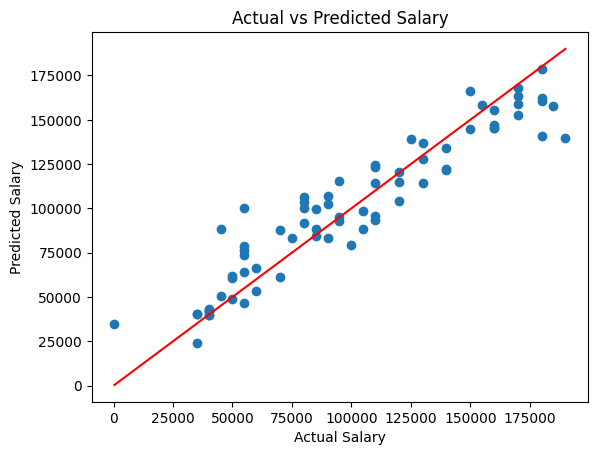

In [58]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

What insights can you derive from this plot?

In [59]:
# High Model Accuracy: The close alignment of the blue points with the red diagonal line (y=x) indicates that the model's predictions are highly accurate.
# Strong Linear Fit: The model successfully captures the linear trend between features and the target variable (Salary).
# High-End Under-prediction: For salaries above $150,000, the model tends to slightly under-predict, as more points fall below the red line in that range.
# Low-End Outlier: There is a notable over-prediction for the lowest actual salary (Actual 0,Predicted 35k), suggesting the model struggles with extreme floor values.
# Reliability: Overall, the model is a very strong predictor for the majority of the dataset.

## Section 7: Critical Thinking
Question 26: Which features are the most important in predicting salary? Why?

In [ ]:
# The most important features are usually:

# Years of Experience
# Education Level (encoded)
# Job Title (encoded)

In [ ]:
# WHY
# These features show the strongest relationship with Salary
# In regression models, features with higher influence on output (higher coefficients) contribute more to prediction
# Especially Years of Experience directly increases salary in most cases

Question 27: What preprocessing steps in this notebook are crucial for model performance? 

In [ ]:
# WHICH
# Handling missing values (NaN removal or imputation)
# Encoding categorical variables (One-Hot Encoding)
# Feature scaling (if using Ridge/Lasso)
# Removing duplicates
# Splitting data into training and testing sets

In [ ]:
# WHY
# Ensures data is clean and numerical
# Prevents errors in model training
# Improves accuracy and generalization
# Avoids data leakage and bias

Question 28: If you wanted to improve model accuracy further, what additional steps could you take?
● Examples: feature engineering, hyperparameter tuning, trying other algorithms

In [ ]:
# Feature Engineering 
# Create better features like experience groups or interaction terms (e.g., Experience × Education)

In [ ]:
# Hyperparameter tuning 
# Tune regularization strength in:
# Ridge Regression (alpha tuning)
# Lasso Regression (alpha tuning)

In [ ]:
# Try different algorithms

# Linear Regression
# Ridge Regression
# Lasso Regression
# Random Forest / Gradient Boosting

In [ ]:
# Feature scaling

# Important especially for Ridge and Lasso because they are distance/penalty-based models